In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
draft = pd.read_csv("../data/mockdraft.csv")
draft.head()

,Pick,Team,Player,Position,School,Height,Weight,Class,Age,PPG,RPG,APG,BPG,SPG
0,1,WAS,AJ Dybantsa,SF,BYU,6-9.75,217,Freshman,19.4,26.4,7.1,3.8,0.4,1.1
1,2,UTA,Darryn Peterson,SG/PG,Kansas,6-5.75,199,Freshman,19.4,25.0,5.2,2.0,0.8,1.8
2,3,MEM,Cameron Boozer,PF,Duke,6-9.5,253,Freshman,18.9,24.2,11.0,4.4,0.7,1.5
3,4,CHI,Caleb Wilson,SF/PF,North Carolina,6-10.5,211,Freshman,19.9,22.8,10.8,3.1,1.6,1.7
4,5,LAC,Keaton Wagler,SG/PG,Illinois,6-6.25,188,Freshman,19.4,19.0,5.4,4.5,0.4,1.0


## NBA Draft Prospect Analysis

This project analyzes the projected first-round prospects in the 2026 NBA Draft and predicts draft selections using prospect performance and ranking data.

In [42]:
draft.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pick      30 non-null     int64  
 1   Team      30 non-null     str    
 2   Player    30 non-null     str    
 3   Position  30 non-null     str    
 4   School    30 non-null     str    
 5   Height    30 non-null     str    
 6   Weight    30 non-null     int64  
 7   Class     30 non-null     str    
 8   Age       30 non-null     float64
 9   PPG       30 non-null     float64
 10  RPG       30 non-null     float64
 11  APG       30 non-null     float64
 12  BPG       30 non-null     float64
 13  SPG       30 non-null     float64
dtypes: float64(6), int64(2), str(6)
memory usage: 3.4 KB


In [43]:
draft.describe()

,Pick,Weight,Age,PPG,RPG,APG,BPG,SPG
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,216.033333,20.533333,20.110000,7.356667,3.783333,1.013333,1.340000
std,8.803408,27.840040,1.297566,2.891527,2.946147,1.608401,0.875227,0.477493
min,1.000000,176.000000,18.900000,13.800000,2.500000,1.100000,0.200000,0.500000
25%,8.250000,186.500000,19.425000,18.650000,4.750000,2.800000,0.325000,1.025000
50%,15.500000,213.000000,20.200000,19.250000,7.500000,3.700000,0.800000,1.300000
75%,22.750000,244.000000,21.125000,21.850000,10.300000,4.475000,1.475000,1.600000
max,30.000000,264.000000,23.700000,26.400000,12.200000,6.900000,4.000000,3.000000


## Top Scoring Prospects

In [44]:
top_scorers = draft.sort_values("PPG", ascending=False)
top_scorers[["Player", "PPG"]].head(10)

,Player,PPG
0,AJ Dybantsa,26.4
20,Labaron Philon Jr.,25.6
1,Darryn Peterson,25.0
2,Cameron Boozer,24.2
6,Darius Acuff Jr.,24.1
18,Ebuka Okorie,23.8
3,Caleb Wilson,22.8
5,Mikel Brown Jr.,22.4
14,Cameron Carr,20.2
9,Nate Ament,20.2


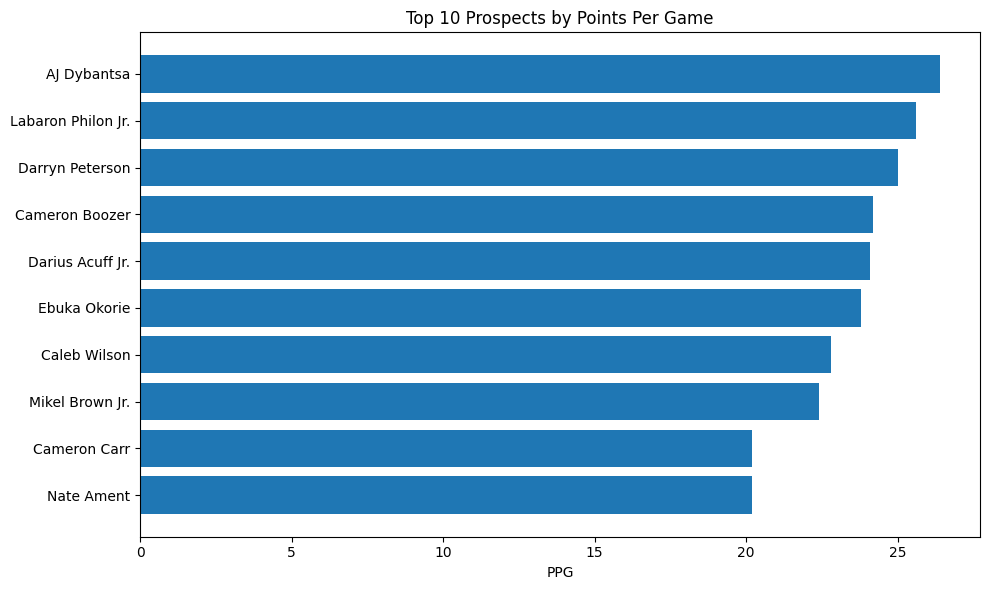

In [45]:
top10 = top_scorers.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Player"], top10["PPG"])

plt.gca().invert_yaxis()

plt.title("Top 10 Prospects by Points Per Game")
plt.xlabel("PPG")

plt.tight_layout()
plt.show()

In [46]:
draft["DraftScore"] = (
    draft["PPG"] * 0.40 +
    draft["RPG"] * 0.20 +
    draft["APG"] * 0.20 +
    draft["BPG"] * 0.10 +
    draft["SPG"] * 0.10
)

## Explanation:

Scoring = 40%
Rebounding = 20%
Assists = 20%
Blocks = 10%
Steals = 10%

In [47]:
rankings = draft.sort_values("DraftScore", ascending=False)
rankings[["Player", "DraftScore"]].head(15)

,Player,DraftScore
2,Cameron Boozer,12.98
0,AJ Dybantsa,12.89
20,Labaron Philon Jr.,12.37
3,Caleb Wilson,12.23
6,Darius Acuff Jr.,11.72
1,Darryn Peterson,11.70
18,Ebuka Okorie,11.19
5,Mikel Brown Jr.,11.11
22,Tarris Reed Jr.,11.10
24,Zuby Ejiofor,10.86


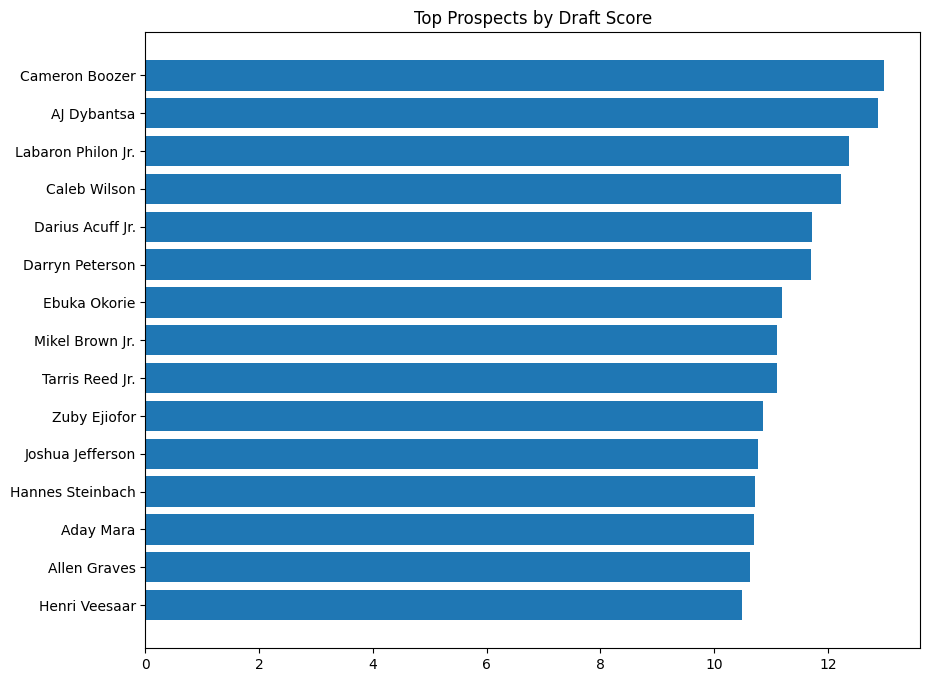

In [48]:
top15 = rankings.head(15)

plt.figure(figsize=(10,8))

plt.barh(top15["Player"], top15["DraftScore"])
plt.gca().invert_yaxis()

plt.title("Top Prospects by Draft Score")

plt.show()

In [49]:
predicted = rankings.copy()

predicted["Predicted Pick"] = range(1, len(predicted)+1)

draft_order = draft[["Pick","Team"]].copy()

draft_order = draft_order.sort_values("Pick")

predicted["Team"] = draft_order["Team"].values

In [50]:
predicted[["Predicted Pick", "Team", "Player", "DraftScore"]]

,Predicted Pick,Team,Player,DraftScore
2,1,WAS,Cameron Boozer,12.98
0,2,UTA,AJ Dybantsa,12.89
20,3,MEM,Labaron Philon Jr.,12.37
3,4,CHI,Caleb Wilson,12.23
6,5,LAC,Darius Acuff Jr.,11.72
1,6,BKN,Darryn Peterson,11.70
18,7,SAC,Ebuka Okorie,11.19
5,8,ATL,Mikel Brown Jr.,11.11
22,9,DAL,Tarris Reed Jr.,11.10
24,10,MIL,Zuby Ejiofor,10.86


In [51]:
comparison = predicted[["Player", "Pick", "Predicted Pick"]].copy()

comparison["Difference"] = (comparison["Pick"] - comparison["Predicted Pick"])

In [52]:
comparison.sort_values("Difference", ascending=False).head(10)

,Player,Pick,Predicted Pick,Difference
20,Labaron Philon Jr.,21,3,18
26,Joshua Jefferson,27,11,16
24,Zuby Ejiofor,25,10,15
22,Tarris Reed Jr.,23,9,14
27,Henri Veesaar,28,15,13
18,Ebuka Okorie,19,7,12
23,Dailyn Swain,24,17,7
29,Sergio de Larrea,30,25,5
17,Allen Graves,18,14,4
6,Darius Acuff Jr.,7,5,2


In [53]:
comparison.sort_values("Difference").head(10)

,Player,Pick,Predicted Pick,Difference
4,Keaton Wagler,5,22,-17
7,Kingston Flemings,8,24,-16
8,Brayden Burries,9,21,-12
15,Christian Anderson,16,27,-11
19,Chris Cenac Jr.,20,30,-10
10,Yaxel Lendeborg,11,20,-9
16,Karim Lopez,17,26,-9
9,Nate Ament,10,16,-6
11,Morez Johnson Jr.,12,18,-6
14,Cameron Carr,15,19,-4


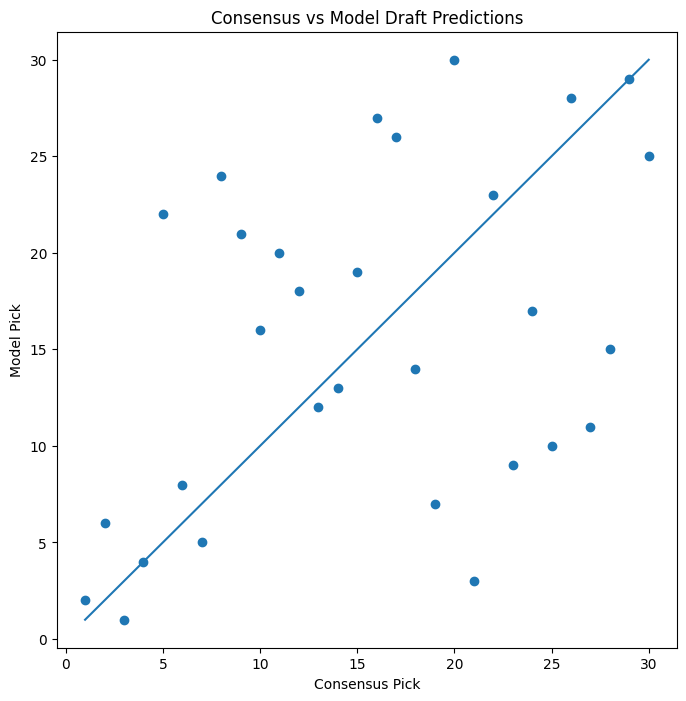

In [54]:
plt.figure(figsize=(8,8))

plt.scatter(comparison["Pick"], comparison["Predicted Pick"])

plt.plot([1,30], [1,30])

plt.xlabel("Consensus Pick")
plt.ylabel("Model Pick")

plt.title("Consensus vs Model Draft Predictions")

plt.show()

In [55]:
predicted.to_csv("../outputs/predicted_draft.csv", index=False)

## Conclusions

A custom Draft Score was developed using prospect offensive and defensive statistics.

The model generated an independent ranking of all projected first-round prospects and identified potential draft risers and fallers relative to the consensus mock draft.

Future improvements could include team needs, historical draft trends, advanced analytics, and machine learning models.

In [56]:
final_board = predicted[[
        "Predicted Pick",
        "Team",
        "Player",
        "Position",
        "School",
        "DraftScore"
    ]]

final_board

,Predicted Pick,Team,Player,Position,School,DraftScore
2,1,WAS,Cameron Boozer,PF,Duke,12.98
0,2,UTA,AJ Dybantsa,SF,BYU,12.89
20,3,MEM,Labaron Philon Jr.,PG,Alabama,12.37
3,4,CHI,Caleb Wilson,SF/PF,North Carolina,12.23
6,5,LAC,Darius Acuff Jr.,PG,Arkansas,11.72
1,6,BKN,Darryn Peterson,SG/PG,Kansas,11.70
18,7,SAC,Ebuka Okorie,PG,Stanford,11.19
5,8,ATL,Mikel Brown Jr.,PG,Louisville,11.11
22,9,DAL,Tarris Reed Jr.,C,UConn,11.10
24,10,MIL,Zuby Ejiofor,PF,St. John's,10.86


In [57]:
final_board.to_csv(
    "../outputs/final_predicted_draft_board.csv",
    index=False
)

In [58]:
final_board.head(15)

,Predicted Pick,Team,Player,Position,School,DraftScore
2,1,WAS,Cameron Boozer,PF,Duke,12.98
0,2,UTA,AJ Dybantsa,SF,BYU,12.89
20,3,MEM,Labaron Philon Jr.,PG,Alabama,12.37
3,4,CHI,Caleb Wilson,SF/PF,North Carolina,12.23
6,5,LAC,Darius Acuff Jr.,PG,Arkansas,11.72
1,6,BKN,Darryn Peterson,SG/PG,Kansas,11.70
18,7,SAC,Ebuka Okorie,PG,Stanford,11.19
5,8,ATL,Mikel Brown Jr.,PG,Louisville,11.11
22,9,DAL,Tarris Reed Jr.,C,UConn,11.10
24,10,MIL,Zuby Ejiofor,PF,St. John's,10.86
